# RF Explorer Calibration

A well known issue in the 2021 MWA beam paper is that the attenuation in the MWA (AUT) side of this signal chain was set too low, and the brightest signals saturated. We attempted to correct for this compression, but it wasn't good enough. Looking at the raw data, it appears that the primary lobe often has a 3dB deficit in measured power, this is 50% in linear units! This notebook is an effort to do better

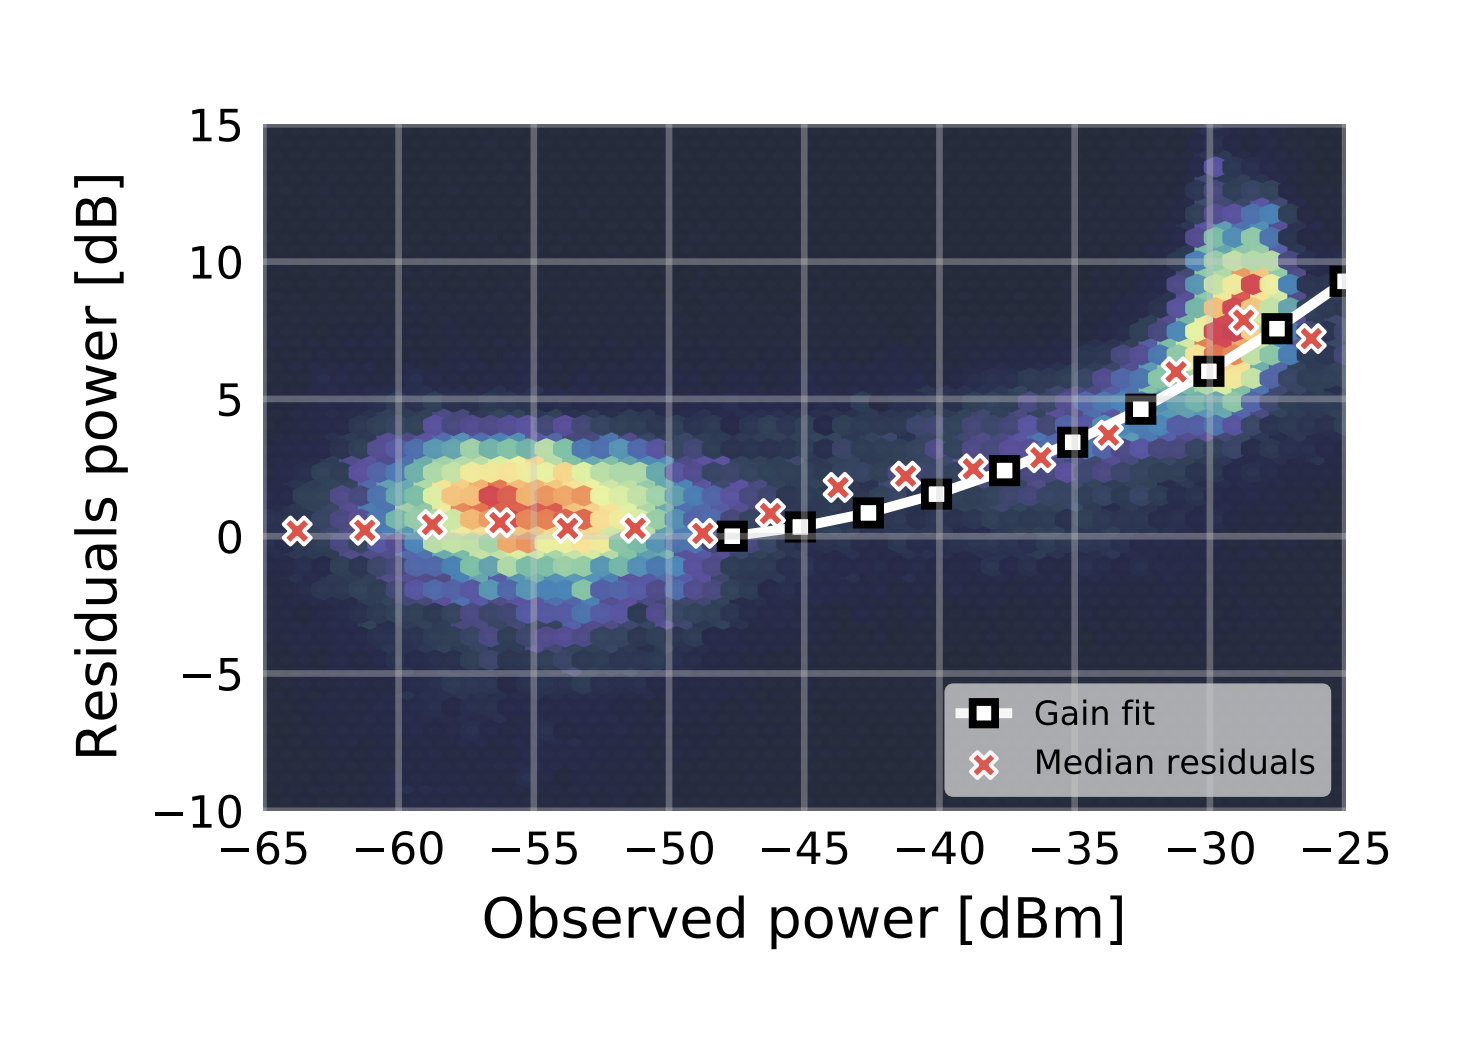

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap as LSC
from scipy.stats import median_abs_deviation as mad
from scipy.stats import binned_statistic, beta
from scipy.optimize import minimize

colors = cmr.pride(np.linspace(0.1, 0.8, 256))
colors[0] = mcolors.to_rgba("whitesmoke")
prd = ListedColormap(colors, name="pride")
prd.set_under("whitesmoke")
# prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
# prd.set_under("white")

### Let's first try and recreate Fig 9 from the paper

In [2]:
rfe_cali_dir = Path("../passes/rfe_cal/original")
gain_files = sorted(rfe_cali_dir.glob("*.json"))

# Combine data from all RF Explorers
pass_data = []
pass_resi = []
# pass_hpx = []

for f in (gain_files):
    with open(f, "r") as data:
        rfe = json.load(data)
        pass_data.extend(rfe["pass_data"])
        pass_resi.extend(rfe["pass_resi"])
        
pass_data = np.array(pass_data)
pass_resi = np.array(pass_resi)

# Clean up any nans, infs
mask = np.isfinite(pass_data) & np.isfinite(pass_resi)
pass_data = pass_data[mask]
pass_resi = pass_resi[mask]
# pass_hpx = pass_hpx[mask]

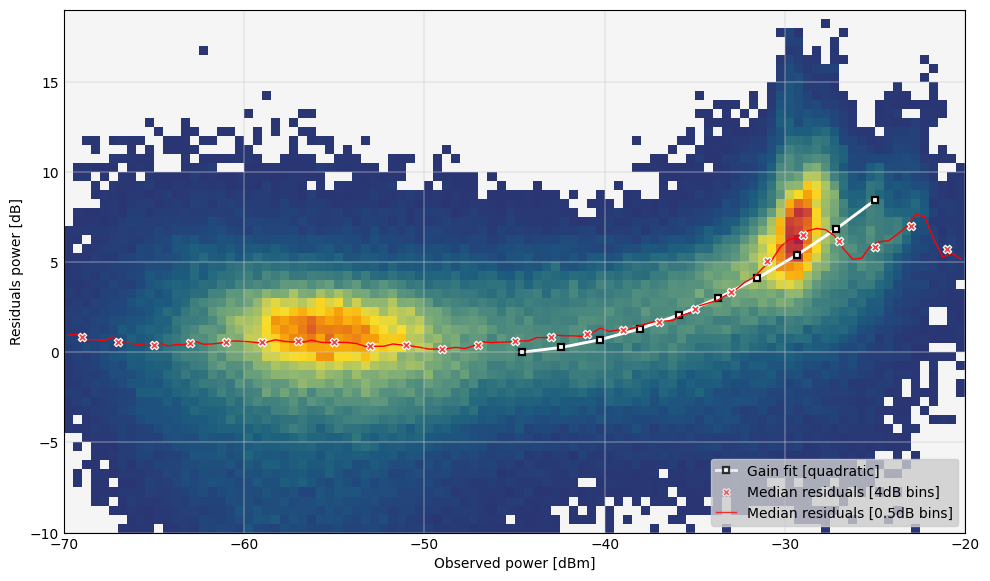

In [3]:
gain_cali_start = -50
gain_cali_stop = -30
data_xlims = (-70, -20)
data_ylims = (-10, 19)

# Crop data - limit to sensible x-range
mask_crop = (
    (pass_data <= data_xlims[1]) & (pass_data >= data_xlims[0])
    & (pass_resi <=data_ylims[1]) & (pass_resi >= data_ylims[0])
    # & (pass_hpx <= 1199)
)

# Now look at data between -50, -30, where gains vary
mask_polyfit = np.where(np.logical_and(pass_data >= gain_cali_start, pass_data <= gain_cali_stop))

# Linear fit to RFE data between -50, -30 dBm
poly = np.polyfit(pass_data[mask_polyfit], pass_resi[mask_polyfit], 2)

# Mathematical function of fit, which can be evaluated anywhere
f = np.poly1d(poly)
x_f = np.linspace(max(f.roots), -25, num=10)
y_f = f(x_f)

# Binned stats 
x_edges_05db = np.linspace(data_xlims[0], data_xlims[1], 2*(data_xlims[1] - data_xlims[0])+1)   # 80 bins = 0.5 dB
y_edges_05db = np.linspace(data_ylims[0], data_ylims[1], 2*(data_ylims[1] - data_ylims[0])+1)
x_centers_05db = 0.5 * (x_edges_05db[:-1] + x_edges_05db[1:])
median_resi_05db, _, _ = binned_statistic(
    pass_data[mask_crop],
    pass_resi[mask_crop],
    statistic="median",
    bins=x_edges_05db,
)

x_edges_4db = np.linspace(data_xlims[0], data_xlims[1], int(0.5*(data_xlims[1] - data_xlims[0])+1))   # 20 bins = 4 dB
y_edges_4db = np.linspace(data_ylims[0], data_ylims[1], int(0.5*(data_ylims[1] - data_ylims[0])+1))
x_centers_4db = 0.5 * (x_edges_4db[:-1] + x_edges_4db[1:])
median_resi_4db, _, _ = binned_statistic(
    pass_data[mask_crop],
    pass_resi[mask_crop],
    statistic="median",
    bins=x_edges_4db,
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.hist2d(
    pass_data[mask_crop],
    pass_resi[mask_crop],
    bins=[x_edges_05db, y_edges_05db],
    cmap=prd,
)

ax.plot(
    x_f,
    y_f,
    color="w",
    lw=2.1,
    marker="s",
    markeredgecolor="k",
    markeredgewidth=1.6,
    markersize=4.9,
    alpha=1,
    label="Gain fit [quadratic]",
    zorder=1,
)
ax.scatter(
    x_centers_4db,
    median_resi_4db,
    marker="X",
    s=36,
    facecolors="#ee4540",
    lw=0.9,
    edgecolors="w",
    alpha=1,
    label="Median residuals [4dB bins]",
    zorder=2,
)

ax.plot(
    x_centers_05db,
    median_resi_05db,
    "r-",
    lw=1,
    zorder=1,
    label="Median residuals [0.5dB bins]",
)

leg = plt.legend(loc="lower right", frameon=True, markerscale=0.9, handlelength=1.4)
leg.get_frame().set_facecolor("#cccccc")
for le in leg.legend_handles:
    le.set_alpha(0.77)

ax.set_xlabel("Observed power [dBm]")
ax.set_ylabel("Residuals power [dB]")
ax.tick_params(axis="both", length=0)
ax.grid(color="#cccccc", alpha=0.36, lw=1.2)

ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Better fitting exploration

Compression curves must physically be monotonically increasing and positive concave. Mike has writting some very fancy fitting code which should obey these physical conditions

In [4]:
def get_Imatr(x, Nc=10):
    """
    Get a design matrix based on Bernstein polynomials where the first coefficient is a constant offset, 
    and the next Nc coefficients parametrize the derivatives. If the coefficients are sorted and positive,
    the resulting polynomial will have a strictly increasing positive derivative (i.e. monotonic and concave up).
    
    Parameters:
        x (array):
            X coordinates of samples, RESCALED to live on [0, 1]. Do not need to be evenly spaced
        Nc (int):
            Degree of polynomial (e.g. Nc = 3 makes a cubic).
            
    Returns:
        Imatr (array):
            Design matrix.
    """
    Nx = len(x)
    Imatr = np.zeros([Nx, Nc + 1])
    Imatr[:, 0] = np.ones(Nx)
    for k in range(1, Nc + 1):
        Imatr[:, k] = beta(k, Nc + 1 - k).cdf(x)
        
    return Imatr

In [5]:
def scale_to_unit(
    x: np.ndarray,
    fit_min: float,
    fit_max: float,
) -> np.ndarray:
    """
    Linearly scale data from [fit_min, fit_max] to [0, 1].

    Parameters
    ----------
    x
        Input data.
    fit_min
        Lower bound of the fitting interval.
    fit_max
        Upper bound of the fitting interval.

    Returns
    -------
    ndarray
        Data scaled to the unit interval.
    """
    x = np.asarray(x, dtype=float)
    return (x - fit_min) / (fit_max - fit_min)


def scale_from_unit(
    u: np.ndarray,
    fit_min: float,
    fit_max: float,
) -> np.ndarray:
    """
    Convert data from the unit interval [0, 1] back to the original scale.

    Parameters
    ----------
    u
        Data in the unit interval.
    fit_min
        Lower bound of the fitting interval.
    fit_max
        Upper bound of the fitting interval.

    Returns
    -------
    ndarray
        Data on the original scale.
    """
    u = np.asarray(u, dtype=float)
    return fit_min + u * (fit_max - fit_min)

In [6]:
def objective(params):
    model = Imatr[:, 1:] @ params
    return np.sum((y_fit - model)**2)

def proxy_objective(y):
    # Hand this to minimize, even though we are really minimizing "objective" -- enforces orderliness of coefficients
    x = np.cumsum(y) 
    return objective(x)

## Let's plot data from indivitual tiles

The data used below was reprocessed by Aman on 20260714 by Aman using a rewritten calibration function, with key values

- MWA FEE nulls masked below -55dB
- TILE Data assumed to start compressing above -40dBm
- Only satellites which pass within 25 deg of zenith are used for RF Explorer amp calibration (They move through main lobe)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 86027.21349934221
        x: [ 3.241e-01  0.000e+00 ...  2.380e-02  3.696e+00]
      nit: 144
      jac: [ 3.621e+00  7.442e+02 ... -1.397e-01 -1.077e-01]
     nfev: 3349
     njev: 197
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


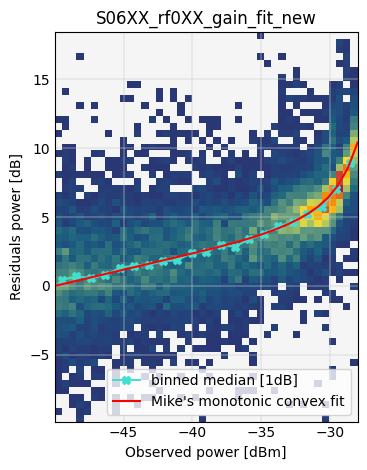

In [7]:
rfe_cali_dir = Path("../passes/rfe_cal/20260714")
gain_files = sorted(rfe_cali_dir.glob("*.json"))

data_xlims = (-50, -28)
data_ylims = (-10, 15)

for f in (gain_files):
    with open(f, "r") as data:
        rfe = json.load(data)
        pass_data = rfe["tile_pass_data"]
        pass_resi = rfe["pass_resi"]
        pass_hpx = rfe["hpx_idx"]

        pass_data = np.array(pass_data)
        pass_resi = np.array(pass_resi)
        pass_hpx = np.array(pass_hpx)

        mask_crop = (
            (pass_data >= data_xlims[0])
            & (pass_data <= data_xlims[1])
            & (pass_resi >= data_ylims[0])
            # & (pass_hpx <= 840)
        )

        x_fit = pass_data[mask_crop]
        y_fit = pass_resi[mask_crop]

        u_fit = scale_to_unit(x_fit, data_xlims[0], x_fit.max())

        Nc = 16
        highval = 5
        Imatr = get_Imatr(u_fit, Nc=Nc)
        x0 = np.zeros(Nc)
        x0[-1] = 0.2

        soln = minimize(proxy_objective, x0=x0, bounds=Nc * [[0, highval]])
        print(soln)

        u_grid=np.linspace(0, 1, 32)
        deriv_coeffs_best = np.cumsum(soln["x"])
        Imatr_grid = get_Imatr(u_grid, Nc=Nc)
        y_grid = Imatr_grid[:, 1:] @ deriv_coeffs_best


        fig, ax = plt.subplots()
        
        ax.hist2d(
            x_fit,
            y_fit,
            bins=(2*int(x_fit.max()-data_xlims[0]), 2*int(y_fit.max()-data_ylims[0])),
            cmap=prd,
        )

        med_resi, be, _ = binned_statistic(x_fit, y_fit, statistic="median", bins=int(x_fit.max()-data_xlims[0]))
        bc = 0.5 * (be[:-1] + be[1:])

        ax.plot(bc, med_resi, color="turquoise", marker="X", ms=6, lw=1.4, label="binned median [1dB]")

        ax.plot(scale_from_unit(u_grid, data_xlims[0], x_fit.max()), y_grid, label="Mike's monotonic convex fit", color="r")
        
        ax.set_xlabel("Observed power [dBm]")
        ax.set_ylabel("Residuals power [dB]")
        ax.tick_params(axis="both", length=0)
        ax.grid(color="#cccccc", alpha=0.36, lw=1.2)
        ax.set_aspect("equal")
        ax.set_title(f.stem)

        ax.legend(loc="lower right")
        
        plt.tight_layout()
        plt.show()
        break

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 96658.74966715429
        x: [ 3.101e-01  5.731e-02 ...  1.722e-02  2.369e-01]
      nit: 20
      jac: [ 1.329e+03  2.217e+03 ...  6.864e+02  3.586e+02]
     nfev: 544
     njev: 32
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


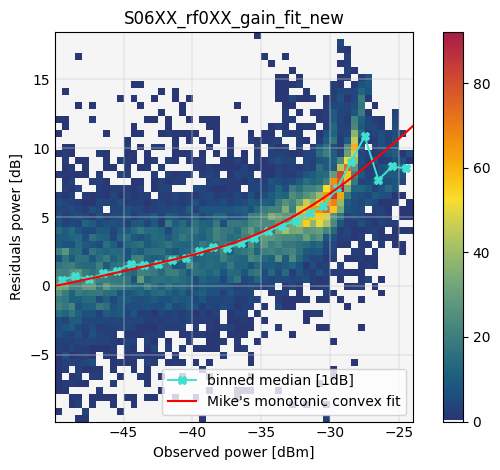

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 87049.61534241514
        x: [ 3.642e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 41
      jac: [ 4.366e-02  9.112e+02 ...  6.026e+02  2.978e+02]
     nfev: 918
     njev: 54
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


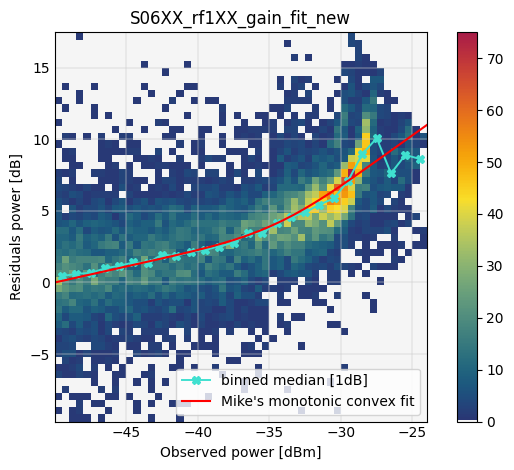

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 89718.99958727784
        x: [ 2.366e-01  5.046e-02 ...  0.000e+00  1.845e-01]
      nit: 15
      jac: [ 3.788e+03  4.503e+03 ...  1.373e+03  5.823e+02]
     nfev: 408
     njev: 24
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


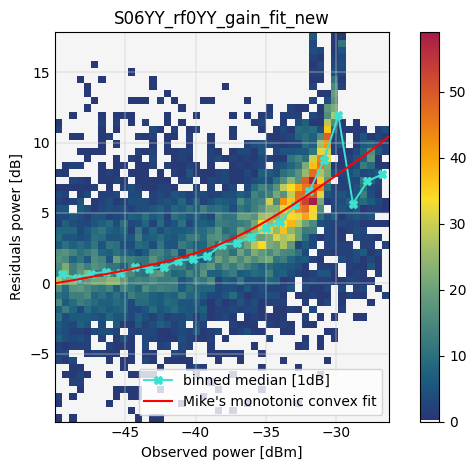

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 97783.53388948404
        x: [ 2.278e-01  7.005e-02 ...  0.000e+00  1.967e-01]
      nit: 13
      jac: [ 4.424e+03  5.233e+03 ...  1.434e+03  6.092e+02]
     nfev: 357
     njev: 21
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


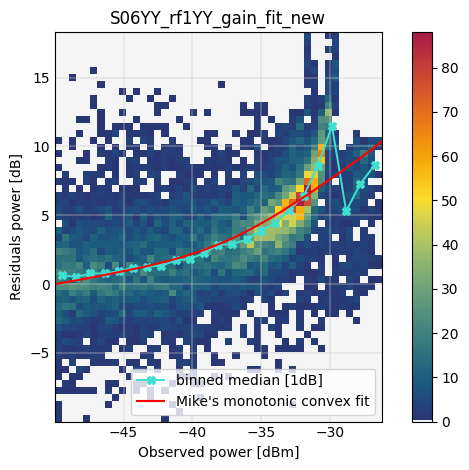

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 113521.1107905912
        x: [ 2.164e-01  1.223e-01 ...  5.621e-02  2.617e-01]
      nit: 7
      jac: [ 6.817e+03  7.683e+03 ...  4.535e+02  2.441e+02]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


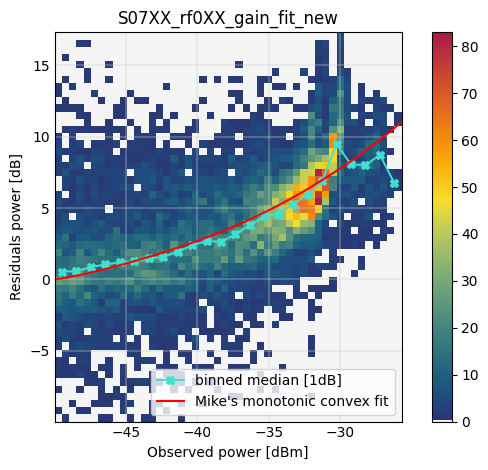

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 113524.61039856555
        x: [ 1.771e-01  1.110e-01 ...  4.175e-02  2.513e-01]
      nit: 7
      jac: [ 7.617e+03  8.058e+03 ...  7.323e+02  3.100e+02]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


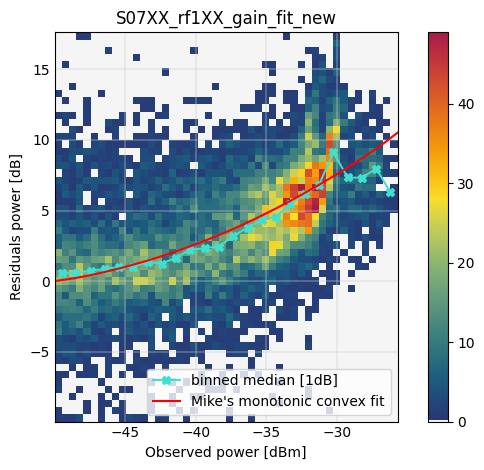

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 82456.3643009273
        x: [ 1.838e-01  4.818e-02 ...  4.390e-02  2.578e-01]
      nit: 20
      jac: [ 3.850e+03  4.255e+03 ...  5.461e+02  2.234e+02]
     nfev: 578
     njev: 34
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


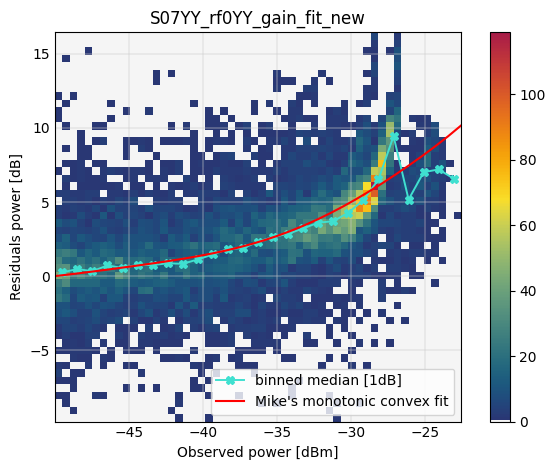

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 89558.30647035612
        x: [ 1.908e-01  0.000e+00 ...  0.000e+00  1.638e-01]
      nit: 28
      jac: [-7.802e+01  6.570e+02 ...  5.778e+02  2.412e+02]
     nfev: 697
     njev: 41
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


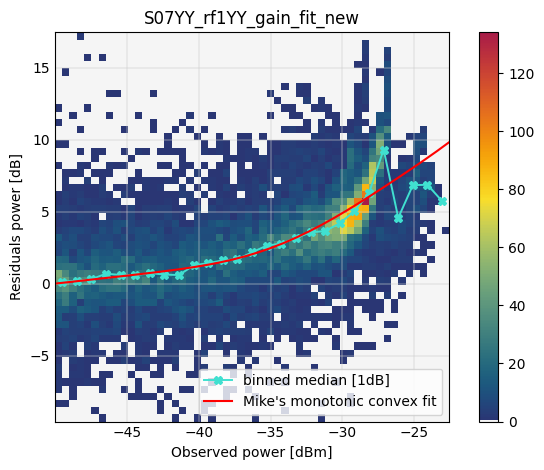

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 109932.96631163711
        x: [ 0.000e+00  2.936e-02 ...  1.107e-01  2.812e-01]
      nit: 21
      jac: [ 2.337e+03  1.116e+03 ...  2.590e+02  1.380e+02]
     nfev: 476
     njev: 28
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


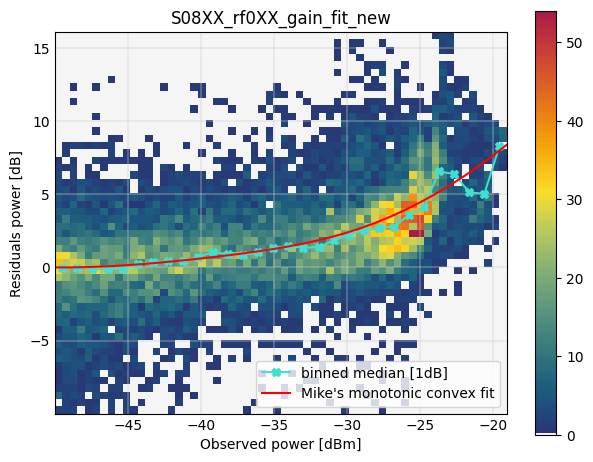

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 108716.09644241612
        x: [ 6.992e-03  6.956e-02 ...  7.992e-02  2.657e-01]
      nit: 8
      jac: [ 1.742e+03  9.428e+02 ...  2.534e+02  1.412e+02]
     nfev: 255
     njev: 15
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


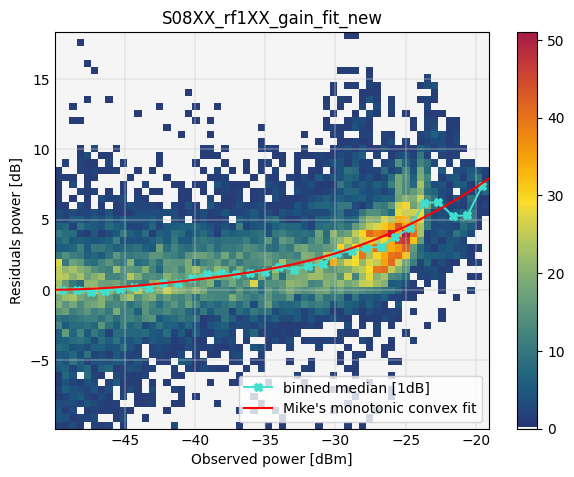

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 117728.65006110707
        x: [ 2.185e-01  7.649e-02 ...  9.631e-04  1.881e-01]
      nit: 11
      jac: [ 1.007e+03  2.475e+03 ...  1.670e+03  6.420e+02]
     nfev: 323
     njev: 19
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


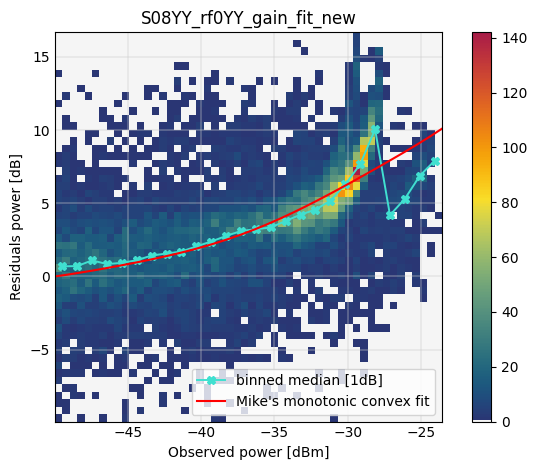

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 123231.30132249522
        x: [ 3.074e-01  0.000e+00 ...  0.000e+00  4.138e-02]
      nit: 28
      jac: [ 3.788e+03  4.061e+03 ...  1.423e+03  5.721e+02]
     nfev: 680
     njev: 40
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


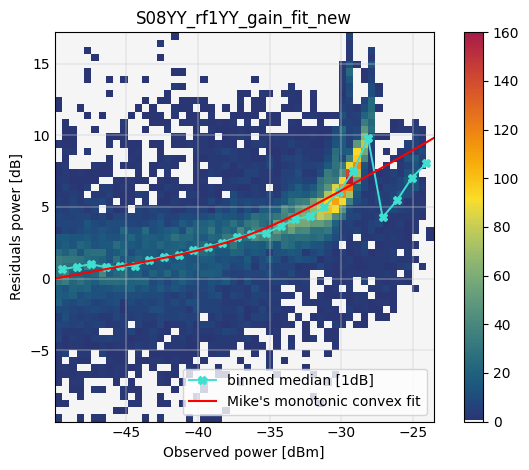

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 73360.91640626549
        x: [ 2.075e-01  1.236e-01 ...  4.301e-02  2.508e-01]
      nit: 7
      jac: [ 5.680e+03  6.656e+03 ...  5.378e+02  2.759e+02]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


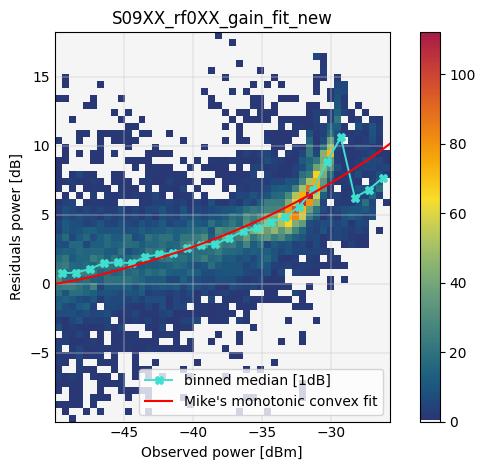

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 71955.58544158078
        x: [ 2.043e-01  1.261e-01 ...  3.968e-02  2.483e-01]
      nit: 7
      jac: [ 5.097e+03  6.063e+03 ...  5.774e+02  2.759e+02]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


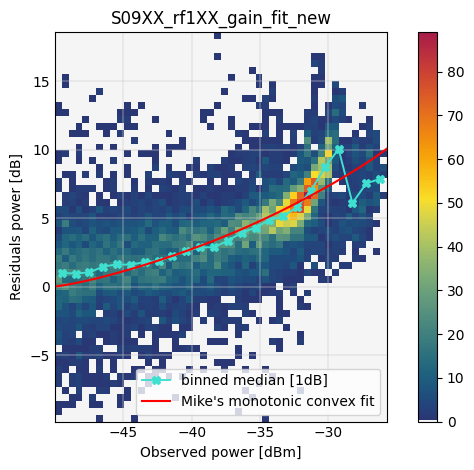

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 64569.86868048452
        x: [ 7.840e-02  1.031e-02 ...  0.000e+00  1.066e-01]
      nit: 21
      jac: [ 2.136e+03  2.126e+03 ...  8.500e+02  3.646e+02]
     nfev: 544
     njev: 32
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


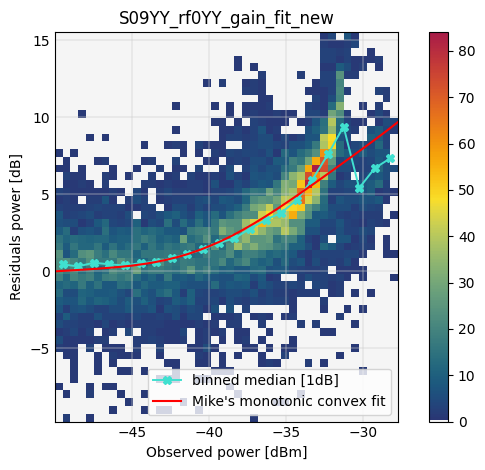

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 70537.38034725297
        x: [ 3.794e-02  9.264e-03 ...  0.000e+00  2.295e-02]
      nit: 24
      jac: [ 4.239e+02  9.383e+02 ...  9.569e+02  4.236e+02]
     nfev: 595
     njev: 35
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


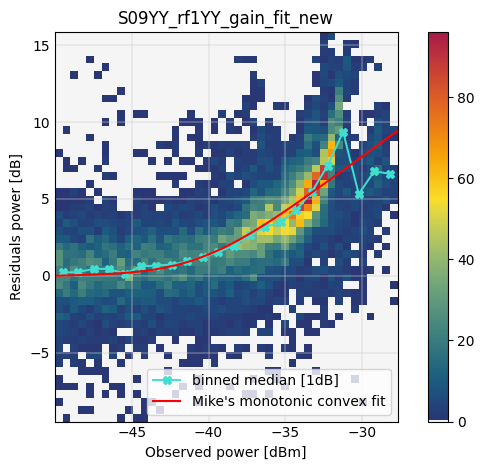

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 57168.423390033684
        x: [ 2.458e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 50
      jac: [-2.357e-01  5.712e+02 ...  3.484e+02  1.495e+02]
     nfev: 1139
     njev: 67
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


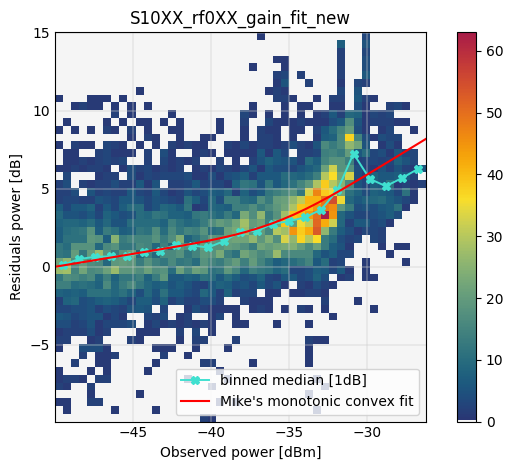

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 56462.00445682182
        x: [ 1.297e-01  7.548e-02 ...  3.038e-02  2.380e-01]
      nit: 7
      jac: [ 5.057e+03  5.067e+03 ...  3.522e+02  1.630e+02]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


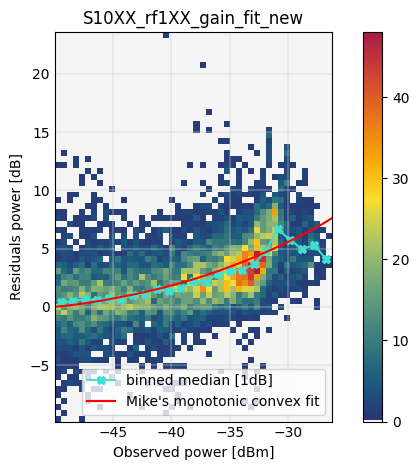

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 59539.15152882837
        x: [ 4.475e-02  2.137e-02 ...  3.443e-02  2.464e-01]
      nit: 7
      jac: [ 1.352e+03  1.855e+03 ...  5.012e+02  2.133e+02]
     nfev: 255
     njev: 15
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


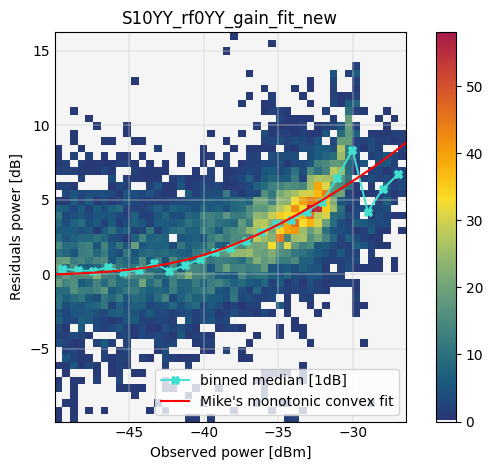

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 66752.35369114252
        x: [ 2.614e-02  1.936e-02 ...  5.499e-02  2.581e-01]
      nit: 6
      jac: [ 7.238e+02  1.048e+03 ...  3.315e+02  1.572e+02]
     nfev: 221
     njev: 13
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


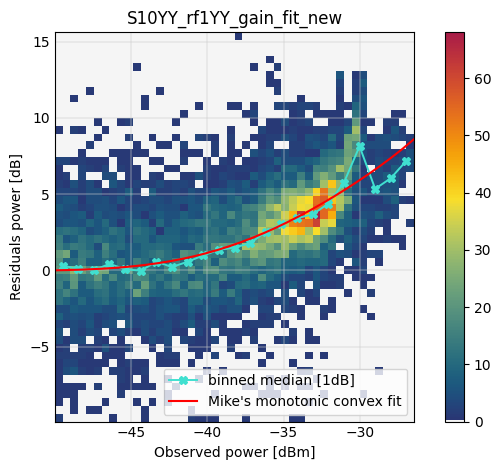

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 52250.03684260136
        x: [ 2.960e-01  1.124e-01 ...  0.000e+00  2.086e-01]
      nit: 19
      jac: [ 2.464e+03  3.210e+03 ...  5.422e+02  1.915e+02]
     nfev: 544
     njev: 32
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


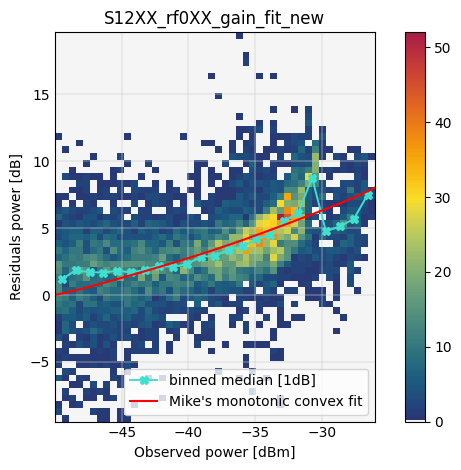

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 49856.36119291341
        x: [ 3.763e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 57
      jac: [-6.548e-03  7.062e+02 ...  7.123e+02  2.501e+02]
     nfev: 1173
     njev: 69
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


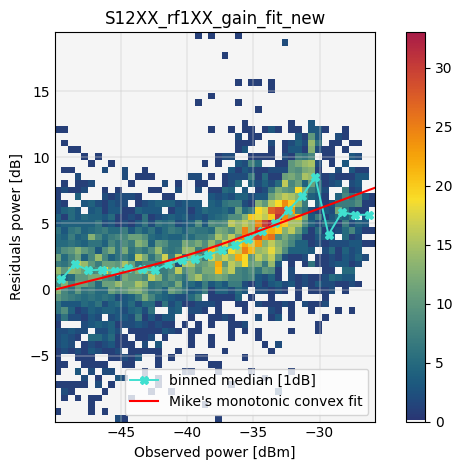

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 59429.844261118335
        x: [ 8.134e-02  7.854e-02 ...  0.000e+00  0.000e+00]
      nit: 41
      jac: [-7.843e+01 -9.593e+00 ...  5.233e+02  1.621e+02]
     nfev: 901
     njev: 53
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


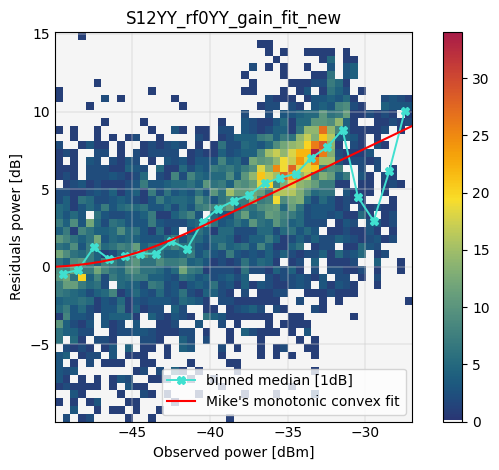

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 67650.49727494533
        x: [ 0.000e+00  9.577e-02 ...  0.000e+00  0.000e+00]
      nit: 36
      jac: [ 4.633e+02  2.841e+02 ...  4.935e+02  1.605e+02]
     nfev: 816
     njev: 48
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


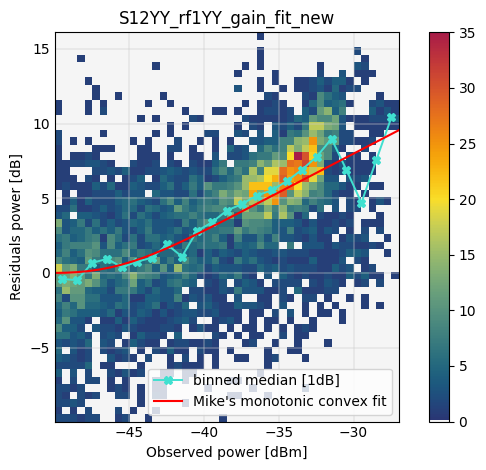

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 79082.96532800904
        x: [ 3.047e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 44
      jac: [ 4.810e+01  3.635e+02 ...  4.280e+02  1.392e+02]
     nfev: 935
     njev: 55
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


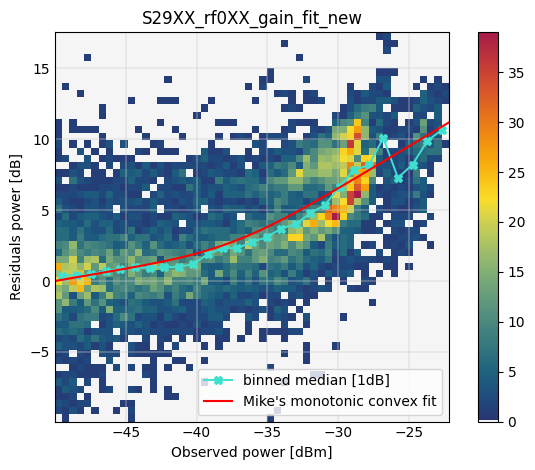

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 71719.6142510483
        x: [ 2.108e-01  7.672e-02 ...  0.000e+00  1.716e-01]
      nit: 13
      jac: [ 1.131e+03  1.534e+03 ...  6.857e+02  2.527e+02]
     nfev: 340
     njev: 20
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


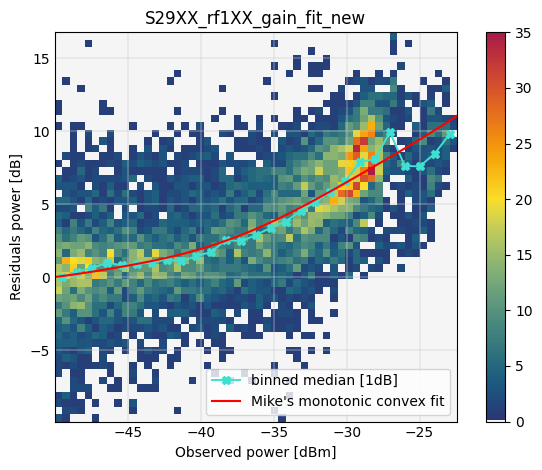

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 47181.02541267378
        x: [ 1.687e-01  2.520e-02 ...  0.000e+00  0.000e+00]
      nit: 35
      jac: [ 2.375e+02  3.224e+02 ...  1.450e+03  5.379e+02]
     nfev: 731
     njev: 43
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


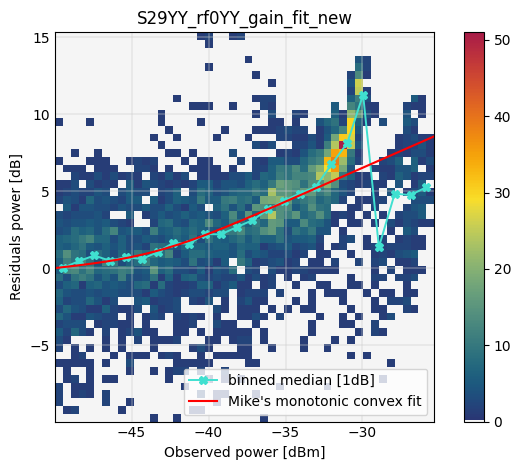

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 47915.382615816496
        x: [ 1.977e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 63
      jac: [-1.455e-03  8.913e+01 ...  1.437e+03  5.309e+02]
     nfev: 1377
     njev: 81
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


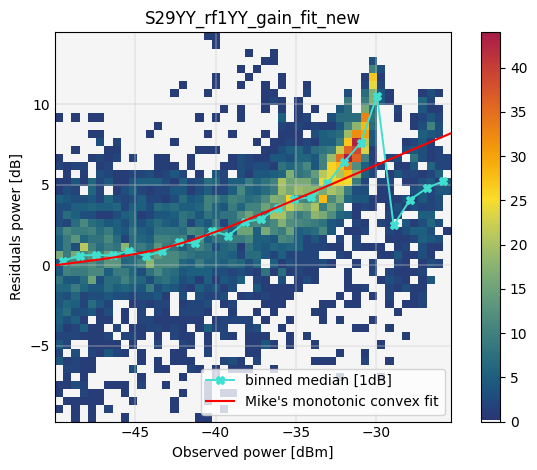

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 83007.25445646836
        x: [ 4.208e-02  2.548e-01 ...  0.000e+00  1.494e-01]
      nit: 27
      jac: [ 3.311e+01  1.646e+02 ...  1.545e+02  5.423e+01]
     nfev: 629
     njev: 37
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


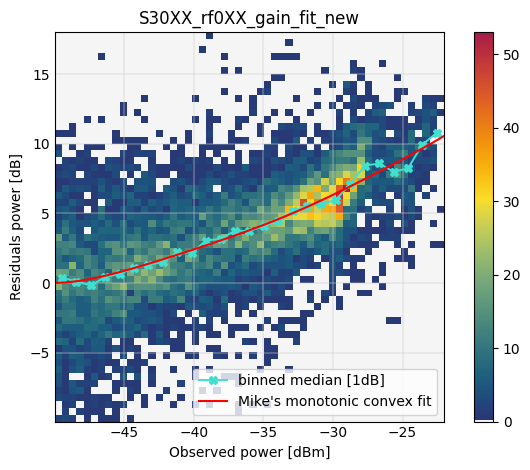

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 82407.00545975179
        x: [ 2.131e-02  2.105e-01 ...  0.000e+00  1.700e-01]
      nit: 21
      jac: [ 6.678e+02  3.596e+02 ...  1.290e+02  4.856e+01]
     nfev: 510
     njev: 30
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


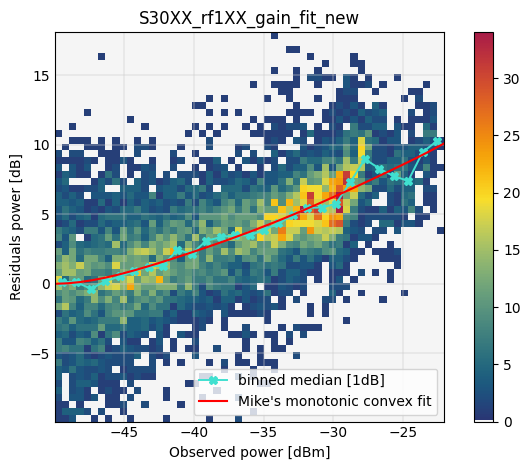

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 135489.32536170608
        x: [ 9.952e-02  4.487e-02 ...  0.000e+00  0.000e+00]
      nit: 33
      jac: [ 2.583e+02  1.488e+02 ...  1.671e+03  7.674e+02]
     nfev: 782
     njev: 46
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


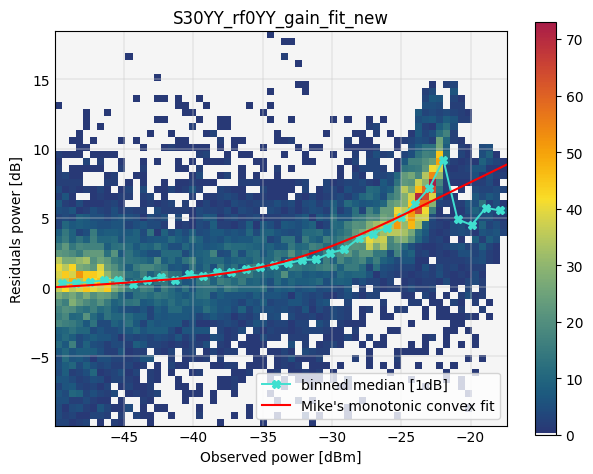

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 149873.09130240534
        x: [ 6.854e-02  6.164e-02 ...  0.000e+00  0.000e+00]
      nit: 35
      jac: [-4.064e+02 -4.424e+02 ...  1.798e+03  8.332e+02]
     nfev: 850
     njev: 50
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


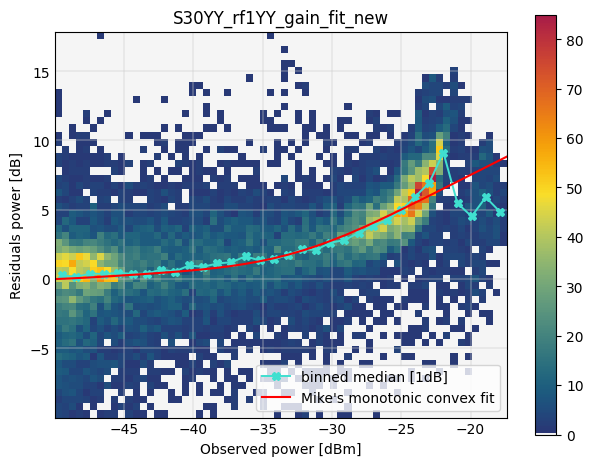

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 52924.66758993896
        x: [ 2.804e-01  5.542e-03 ...  0.000e+00  6.477e-02]
      nit: 26
      jac: [ 6.129e+02  1.070e+03 ...  9.528e+02  3.463e+02]
     nfev: 578
     njev: 34
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


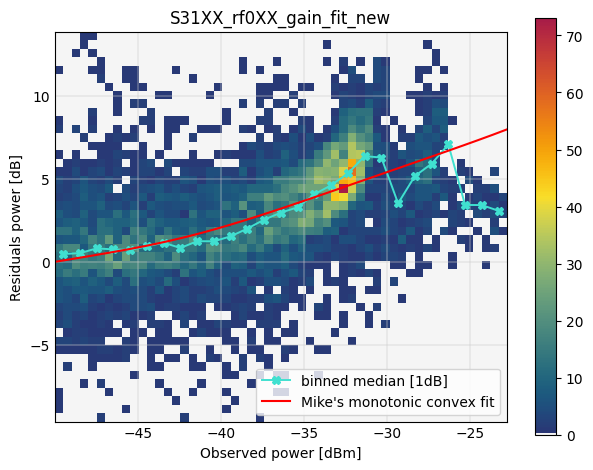

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 49481.24131013226
        x: [ 2.740e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 37
      jac: [-1.455e-03  2.713e+02 ...  8.308e+02  3.043e+02]
     nfev: 799
     njev: 47
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


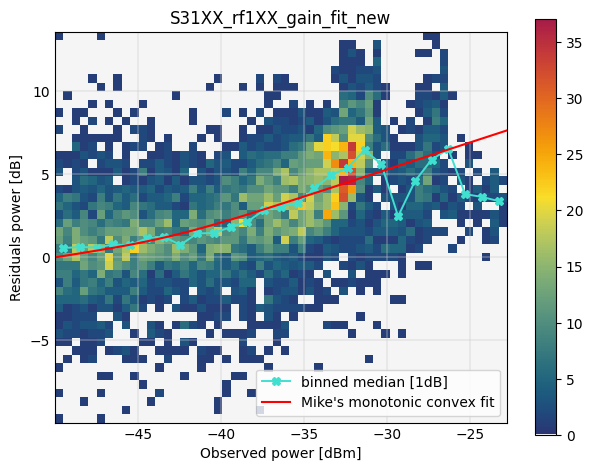

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 39528.88101334864
        x: [ 1.416e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 41
      jac: [ 5.163e+02  8.828e+02 ...  3.129e+02  8.192e+01]
     nfev: 935
     njev: 55
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


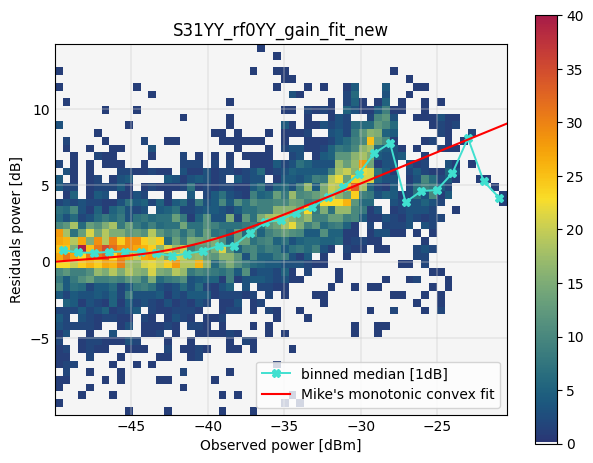

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 40034.164228673646
        x: [ 5.150e-02  4.598e-02 ...  4.646e-02  2.502e-01]
      nit: 9
      jac: [ 5.119e+03  5.233e+03 ...  3.574e+02  9.404e+01]
     nfev: 357
     njev: 21
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


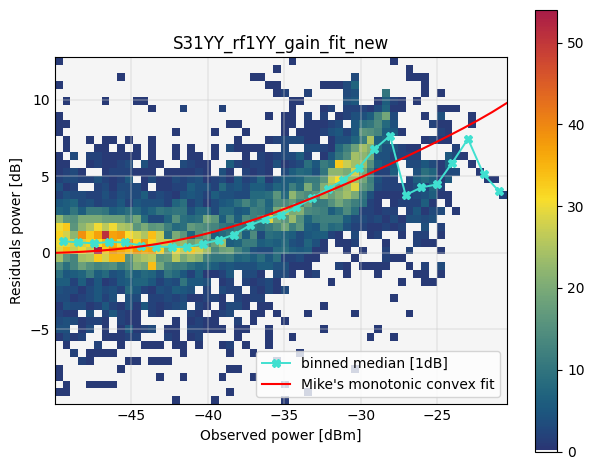

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 81383.04067202864
        x: [ 3.587e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 51
      jac: [ 0.000e+00  2.186e+02 ...  7.664e+02  2.671e+02]
     nfev: 1071
     njev: 63
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


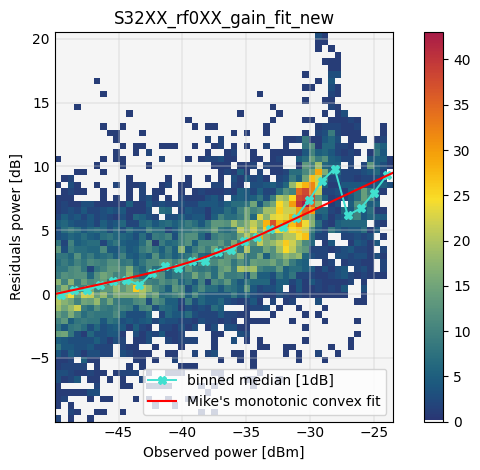

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 82346.07184639276
        x: [ 3.545e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 52
      jac: [ 0.000e+00  5.225e+01 ...  9.530e+02  3.405e+02]
     nfev: 1139
     njev: 67
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


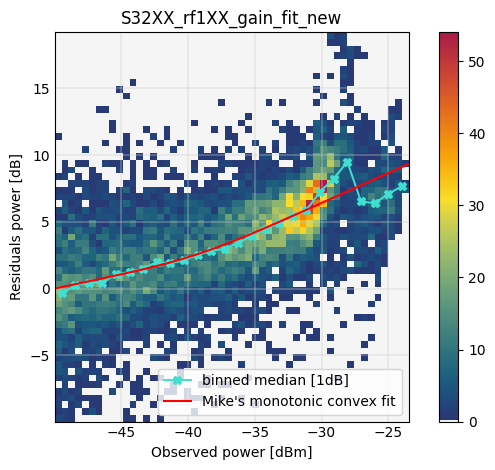

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 55146.11716607884
        x: [ 1.335e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 34
      jac: [ 4.442e+01  2.957e+02 ...  1.183e+03  3.562e+02]
     nfev: 765
     njev: 45
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


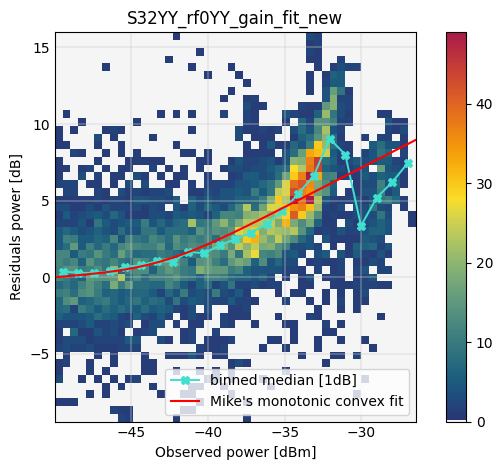

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 53734.39943014545
        x: [ 1.274e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 57
      jac: [-3.638e-03  2.167e+02 ...  1.117e+03  3.436e+02]
     nfev: 1105
     njev: 65
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


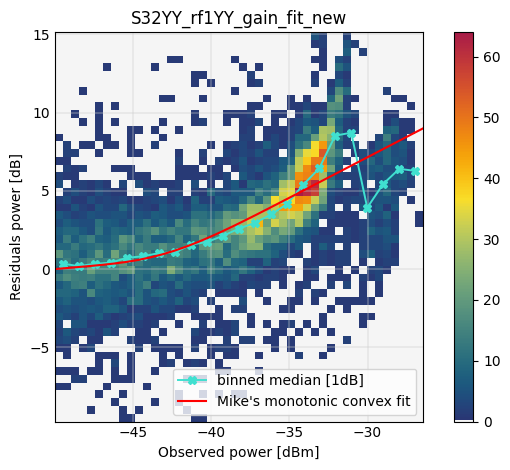

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 61352.806240384874
        x: [ 1.029e-01  5.242e-02 ...  8.719e-02  2.885e-01]
      nit: 7
      jac: [ 2.207e+03  3.094e+03 ...  1.982e+02  6.166e+01]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


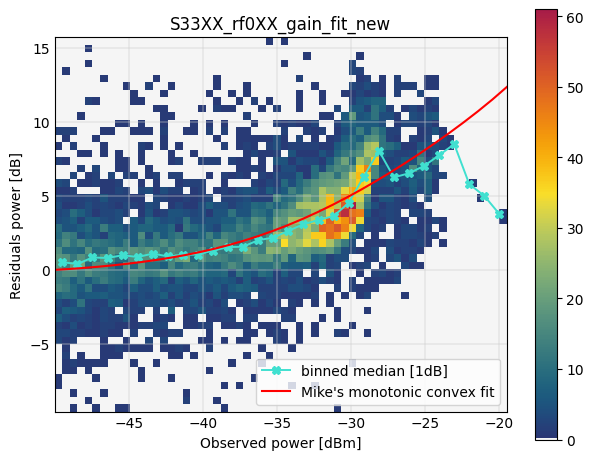

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 61106.940415973004
        x: [ 9.489e-02  5.054e-02 ...  8.358e-02  2.861e-01]
      nit: 7
      jac: [ 2.507e+03  3.179e+03 ...  1.909e+02  5.808e+01]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


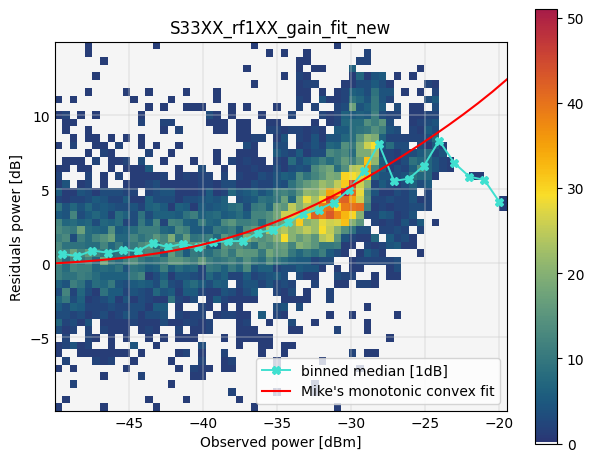

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 117165.2972613207
        x: [ 2.323e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 56
      jac: [-5.166e-01  4.829e+02 ...  9.480e+02  2.452e+02]
     nfev: 1173
     njev: 69
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


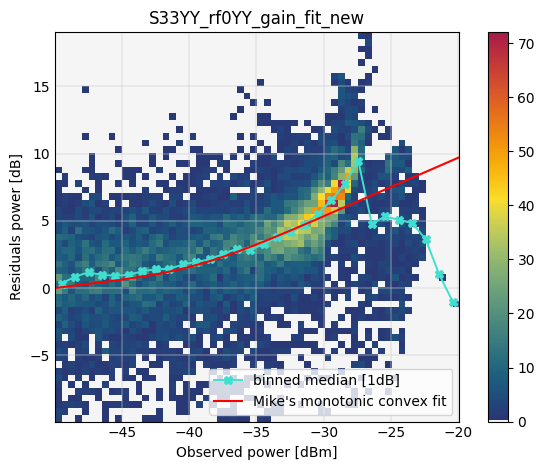

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 128381.11528457188
        x: [ 1.575e-01  2.724e-02 ...  0.000e+00  1.566e-01]
      nit: 19
      jac: [ 9.009e+02  1.442e+03 ...  9.748e+02  2.528e+02]
     nfev: 459
     njev: 27
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


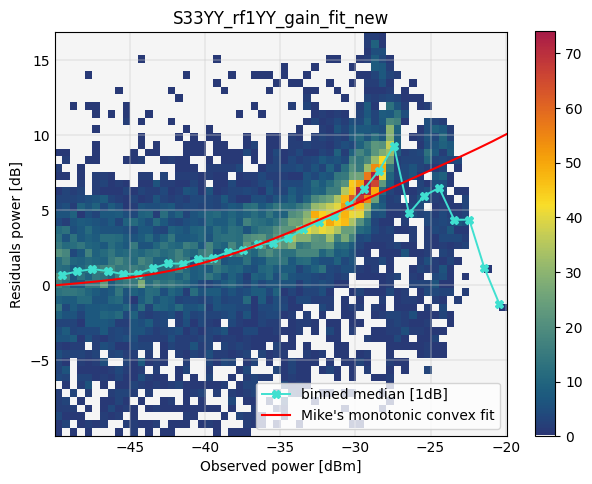

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 82472.9948876976
        x: [ 1.751e-01  6.369e-02 ...  1.147e-02  2.187e-01]
      nit: 12
      jac: [ 6.406e+02  7.626e+02 ...  1.738e+02  1.008e+02]
     nfev: 323
     njev: 19
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


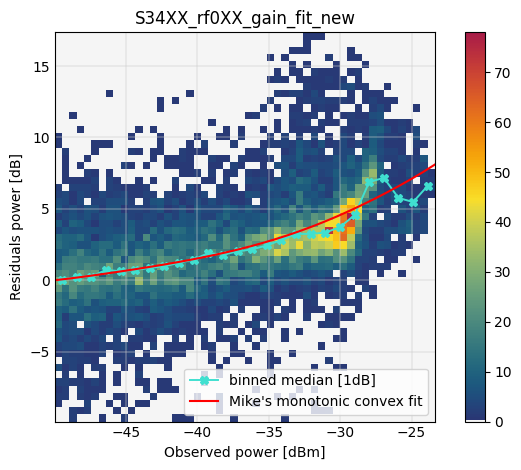

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 73068.85050149132
        x: [ 2.217e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 52
      jac: [ 1.114e+02  1.344e+02 ...  9.267e+01  6.016e+01]
     nfev: 1122
     njev: 66
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


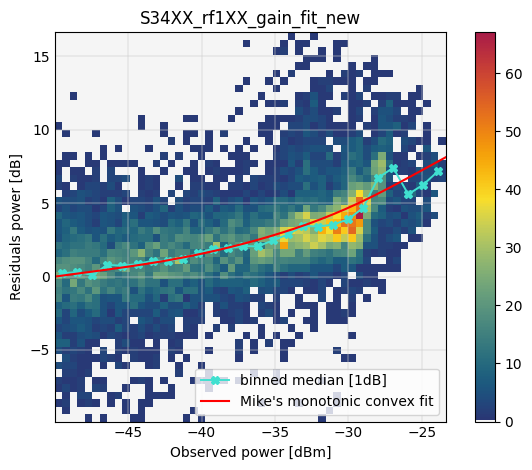

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 78313.8920287333
        x: [ 3.242e-01  7.749e-02 ...  0.000e+00  2.283e-01]
      nit: 16
      jac: [ 6.407e+02  1.498e+03 ...  2.910e+02  8.171e+01]
     nfev: 425
     njev: 25
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


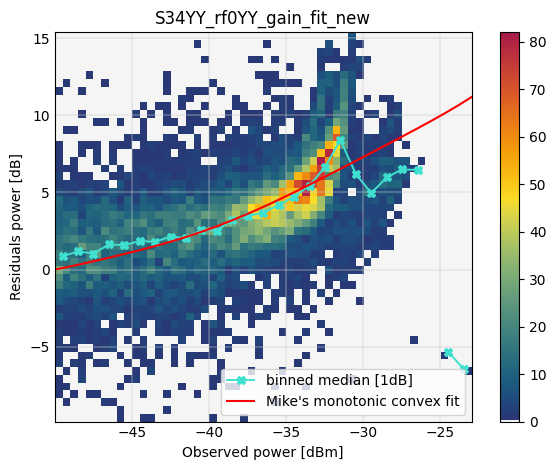

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 82423.83779416583
        x: [ 3.597e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 47
      jac: [-2.095e-01  8.437e+02 ...  3.237e+02  8.970e+01]
     nfev: 1003
     njev: 59
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


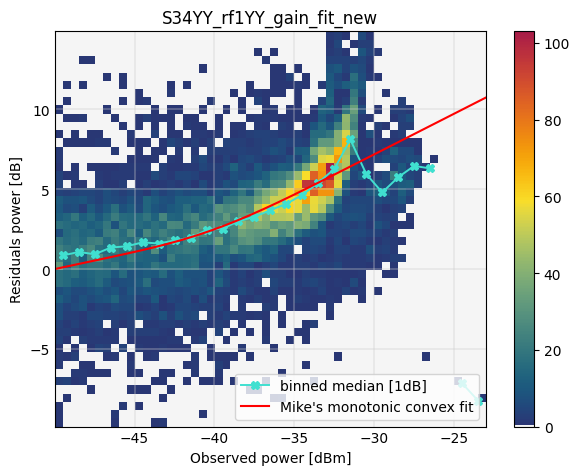

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 80030.40711829465
        x: [ 3.600e-01  1.448e-03 ...  0.000e+00  1.587e-01]
      nit: 29
      jac: [ 9.600e+02  1.429e+03 ...  6.736e+02  2.738e+02]
     nfev: 765
     njev: 45
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


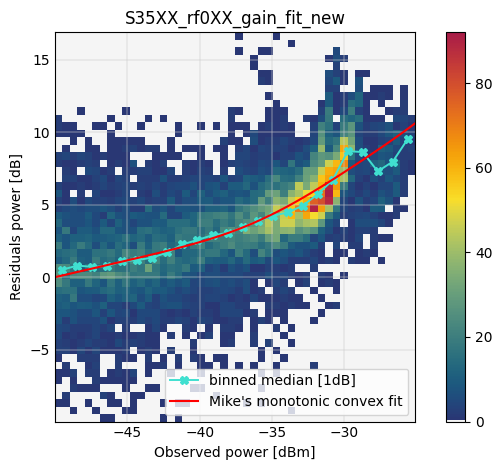

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 89689.51119541482
        x: [ 2.247e-01  1.193e-01 ...  1.232e-02  2.345e-01]
      nit: 7
      jac: [ 4.644e+03  4.783e+03 ...  5.430e+02  2.411e+02]
     nfev: 255
     njev: 15
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


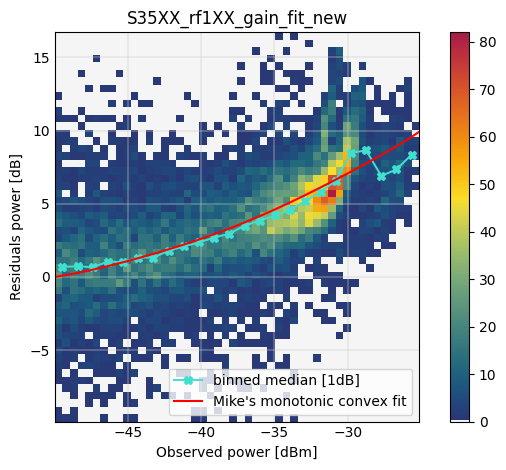

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 76067.13820729045
        x: [ 3.834e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 46
      jac: [ 3.856e-01  6.492e+02 ...  1.037e+02  5.056e+01]
     nfev: 952
     njev: 56
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


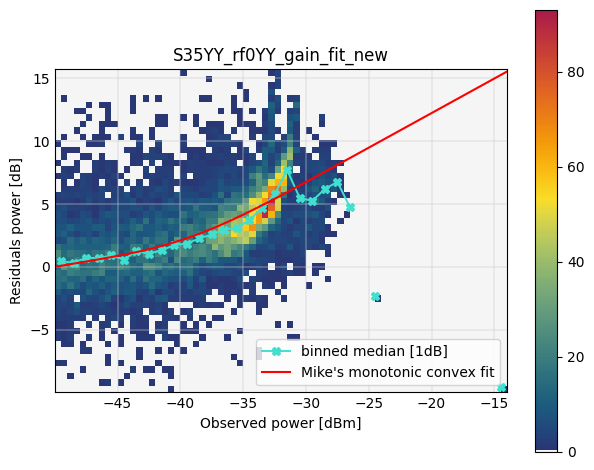

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 83526.5263470004
        x: [ 3.696e-01  2.578e-06 ...  0.000e+00  0.000e+00]
      nit: 42
      jac: [ 1.404e+02  6.484e+02 ...  1.031e+02  5.017e+01]
     nfev: 918
     njev: 54
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


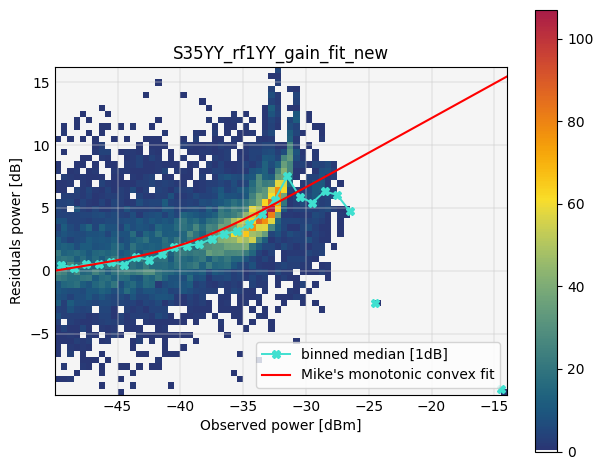

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 77062.61809042394
        x: [ 2.999e-01  1.149e-01 ...  7.590e-02  2.695e-01]
      nit: 13
      jac: [ 1.237e+03  3.339e+03 ...  3.344e+02  1.864e+02]
     nfev: 357
     njev: 21
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


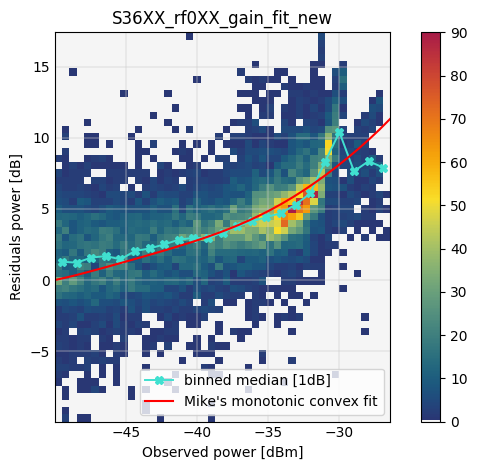

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 68462.77966210857
        x: [ 2.438e-01  1.395e-01 ...  5.826e-02  2.578e-01]
      nit: 7
      jac: [ 4.236e+03  5.451e+03 ...  4.043e+01  6.786e+01]
     nfev: 238
     njev: 14
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


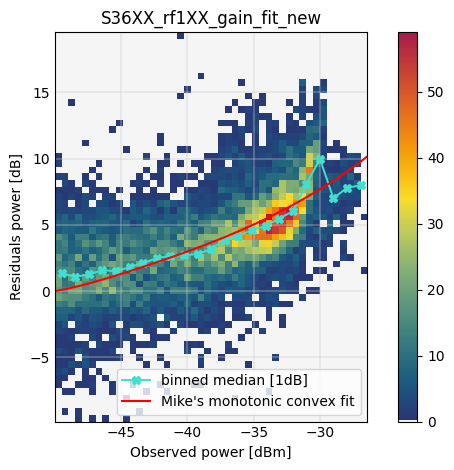

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 96036.45495393682
        x: [ 2.573e-01  0.000e+00 ...  0.000e+00  0.000e+00]
      nit: 55
      jac: [ 8.295e-02  5.072e+02 ...  4.230e+02  9.849e+01]
     nfev: 1156
     njev: 68
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


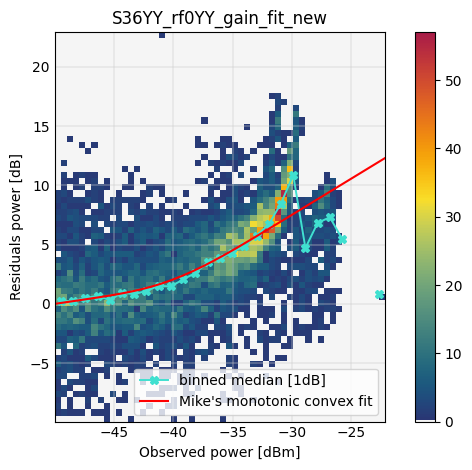

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 109664.91225449866
        x: [ 2.860e-01  0.000e+00 ...  0.000e+00  1.713e-01]
      nit: 30
      jac: [ 1.045e+03  1.342e+03 ...  4.021e+02  9.459e+01]
     nfev: 697
     njev: 41
 hess_inv: <16x16 LbfgsInvHessProduct with dtype=float64>


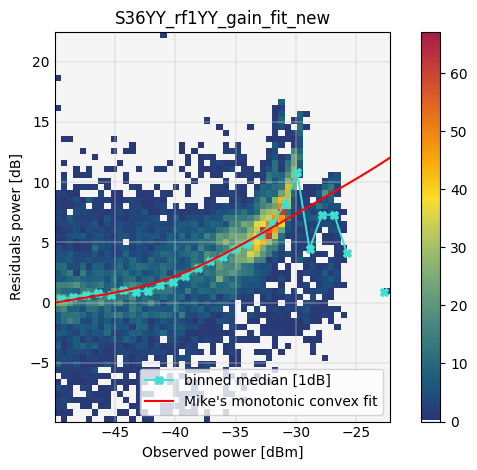

In [8]:
rfe_cali_dir = Path("../passes/rfe_cal/20260714")
gain_files = sorted(rfe_cali_dir.glob("*.json"))

data_xlims = (-50, -27)
data_ylims = (-10, 15)

for f in (gain_files):
    with open(f, "r") as data:
        rfe = json.load(data)
        pass_data = rfe["tile_pass_data"]
        pass_resi = rfe["pass_resi"]
        pass_hpx = rfe["hpx_idx"]

        pass_data = np.array(pass_data)
        pass_resi = np.array(pass_resi)
        pass_hpx = np.array(pass_hpx)

        mask_crop = (
            (pass_data >= data_xlims[0])
            # & (pass_data <= data_xlims[1])
            & (pass_resi >= data_ylims[0])
            # & (pass_hpx <= 840)
        )

        x_fit = pass_data[mask_crop]
        y_fit = pass_resi[mask_crop]

        u_fit = scale_to_unit(x_fit, data_xlims[0], x_fit.max())

        Nc = 16
        highval = 5
        Imatr = get_Imatr(u_fit, Nc=Nc)
        x0 = np.zeros(Nc)
        x0[-1] = 0.2

        soln = minimize(proxy_objective, x0=x0, bounds=Nc * [[0, highval]])
        print(soln)

        u_grid=np.linspace(0, 1, 32)
        deriv_coeffs_best = np.cumsum(soln["x"])
        Imatr_grid = get_Imatr(u_grid, Nc=Nc)
        y_grid = Imatr_grid[:, 1:] @ deriv_coeffs_best


        fig, ax = plt.subplots()
        
        h = ax.hist2d(
            x_fit,
            y_fit,
            bins=(2*int(x_fit.max()-data_xlims[0]), 2*int(y_fit.max()-data_ylims[0])),
            cmap=prd,
        )

        med_resi, be, _ = binned_statistic(x_fit, y_fit, statistic="median", bins=int(x_fit.max()-data_xlims[0]))
        bc = 0.5 * (be[:-1] + be[1:])

        ax.plot(bc, med_resi, color="turquoise", marker="X", ms=6, lw=1.4, label="binned median [1dB]")

        fig.colorbar(h[3])

        ax.plot(scale_from_unit(u_grid, data_xlims[0], x_fit.max()), y_grid, label="Mike's monotonic convex fit", color="r")
        
        ax.set_xlabel("Observed power [dBm]")
        ax.set_ylabel("Residuals power [dB]")
        ax.tick_params(axis="both", length=0)
        ax.grid(color="#cccccc", alpha=0.36, lw=1.2)
        ax.set_aspect("equal")
        ax.set_title(f.stem)

        ax.legend(loc="lower right")
        
        plt.tight_layout()
        plt.show()
        # break